In [1]:
# Repo-root bootstrap: find the directory containing the `llm_perf` package
# (walking up from CWD) and chdir there so paths like "llm_perf/database/..."
# and "assets/..." resolve regardless of where the notebook lives on disk.
import os
from pathlib import Path
_p = Path.cwd()
while not (_p / "llm_perf" / "__init__.py").exists():
    if _p == _p.parent:
        raise RuntimeError("Could not find llm_perf repo root from " + str(Path.cwd()))
    _p = _p.parent
os.chdir(_p)
print("cwd:", Path.cwd())

cwd: /Users/jasonlu/Projects/ai.cluster/llm_perf


# Partition-Optimal Pareto Frontiers vs. Scale-up I/O

**Question:** how does the (throughput/GPU, interactivity) Pareto frontier shift as we vary scale-up I/O bandwidth and latency, and which (PP, TP, EP, SP) partition wins at each frontier corner?

**Method:** for each I/O spec, sweep all valid (PP, TP, EP, SP) partitions × batch sizes B, keep the upper-right envelope in (tput/GPU, 1/TPOT) space, and record the winning partition at each frontier point.

Model, system, and tuner are configured in Section 1 — swap the database paths there to study a different setup.

## 1. Imports and spec loading

In [2]:
from __future__ import annotations

import math
from copy import deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt

from llm_perf import InferenceCalculator
from llm_perf.core.kv_paging_model import KVPagingConfig, compute_kv_paging
from llm_perf.core.memory_model import compute_memory
from llm_perf.io import load_model_spec, load_system_spec, load_tuning_spec
from llm_perf.specs.partition_spec import PartitionSpec
from llm_perf.specs.system_spec import span_tiers

# Configuration — matches the NVIDIA inference blog (GPT-1.8T MoE @ FP4,
# GB200 NVL72). Swap these paths to study a different model/system.
MODEL = "llm_perf/database/model/gpt_1_8t_moe.json"
SYSTEM = "llm_perf/database/system/gb200.72gpu.json"
TUNER = "llm_perf/database/tuner/gpt_1_8t_moe.tuner.json"

S_DECODE = 8192
BPP_FP4 = 0.5  # GB200 inference precision.

model = load_model_spec(MODEL)
model.bytes_per_param = BPP_FP4
system = load_system_spec(SYSTEM)
tuner_base = load_tuning_spec(TUNER)
tuner_base.S_decode = S_DECODE
tuner_base.B_decode = 1

hbm_bw = system.device.hbm_bandwidth_GBps
base_alpha, base_bw, _ = span_tiers(system.get_tier_chain('TP'), 2)
peak_tf = system.device.peak_flops_TF
print(f"Model: {model.name}  L={model.L}  H={model.H}  n_kv={model.n_kv}  bytes/param={model.bytes_per_param}")
print(f"System: {system.num_devices} GPUs  HBM={hbm_bw:.0f} GB/s  peak={peak_tf:.0f} TF  scale-up={base_bw:.0f} GB/s · {base_alpha:.2f} μs")

Model: GPT-1.8T-MoE  L=120  H=20480  n_kv=16  bytes/param=0.5
System: 72 GPUs  HBM=8000 GB/s  peak=9000 TF  scale-up=900 GB/s · 0.50 μs


## 2. Partition enumeration

GPT-1.8T MoE imposes divisibility constraints: `PP | L=120`, `TP | n_kv=16` and `H=20480`, `EP | n_experts=16`. We keep `SP=1`. Candidates exceeding 72 GPUs are dropped.

In [3]:
PP_CHOICES = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 24, 30, 40, 60]
TP_CHOICES = [1, 2, 4, 8, 16]
EP_CHOICES = [1, 2, 4, 8, 16]
SP_CHOICES = [1, 2, 4, 8, 16, 32, 64]


def enumerate_partitions(num_devices: int) -> list[PartitionSpec]:
    out: list[PartitionSpec] = []
    for pp in PP_CHOICES:
        for tp in TP_CHOICES:
            for ep in EP_CHOICES:
                for sp in SP_CHOICES:
                    if pp * tp * ep * sp > num_devices:
                        continue
                    out.append(PartitionSpec(PP=pp, TP=tp, EP=ep, SP=sp))
    return out


partitions = enumerate_partitions(system.num_devices)
print(f"Valid partitions: {len(partitions)}")

Valid partitions: 304


## 3. Partition sweep + Pareto frontier helpers

For each partition we derive `B_max` from the KV paging model and sweep log-spaced batch sizes. Each evaluation produces a point in (tput/GPU, 1/TPOT) space. We then walk the points in order of decreasing tput/GPU and keep those that strictly improve interactivity — the upper-right envelope.

In [4]:
@dataclass
class Point:
    partition: PartitionSpec
    B: int
    tput_per_gpu: float
    interactivity: float
    TPOT_ms: float

    @property
    def part_label(self) -> str:
        p = self.partition
        return f"PP={p.PP} TP={p.TP} EP={p.EP} SP={p.SP}"


def log_spaced_batch_sizes(b_max: int) -> list[int]:
    if b_max <= 1:
        return [1]
    n = max(int(math.log10(b_max) * 10), 16)
    raw = {1, b_max}
    for i in range(n + 1):
        raw.add(max(1, int(round(10 ** (i * math.log10(b_max) / n)))))
    p = 1
    while p <= b_max:
        raw.add(p)
        p *= 2
    return sorted(raw)


def sweep_partition(model, system, partition, tuner_base) -> list[Point]:
    try:
        mem = compute_memory(model, system, partition, tuner_base)
    except Exception:
        return []
    paging = KVPagingConfig(block_size=16, beam_width=1, system_overhead_GB=1.5)
    kv = compute_kv_paging(model, system, partition, tuner_base, mem, paging)
    b_max = int(kv.max_sequences)
    if b_max < 1:
        return []

    pts: list[Point] = []
    for B in log_spaced_batch_sizes(b_max):
        tuner = deepcopy(tuner_base)
        tuner.B_decode = B
        try:
            r = InferenceCalculator(model, system, partition, tuner).run()
        except Exception:
            continue
        if r.latency.TPOT <= 0:
            continue
        pts.append(Point(
            partition=partition,
            B=B,
            tput_per_gpu=r.latency.TTPS / system.num_devices,
            interactivity=1.0 / r.latency.TPOT,
            TPOT_ms=r.latency.TPOT * 1e3,
        ))
    return pts


def pareto_frontier(points: list[Point]) -> list[Point]:
    sorted_pts = sorted(points, key=lambda p: (-p.tput_per_gpu, -p.interactivity))
    frontier: list[Point] = []
    best_interact = -math.inf
    for p in sorted_pts:
        if p.interactivity > best_interact + 1e-9:
            frontier.append(p)
            best_interact = p.interactivity
    frontier.sort(key=lambda p: p.tput_per_gpu)
    return frontier

## 4. Scale-up I/O scaling helper

The scale-up fabric carries TP/EP/SP/PP collectives. Scaling the BW or α multiplier applies uniformly to all four roles — a pure hypothetical sweep of the scale-up pipe.

In [5]:
def scale_system_io(base_system, bw_mult: float, alpha_mult: float):
    """Scale every tier of every fabric — BW by bw_mult, α by alpha_mult.

    All scale-up collectives (TP/EP/SP/PP) cost through these same fabrics,
    so mutating the fabric tiers directly is a pure hypothetical sweep of
    the scale-up pipe.
    """
    s = deepcopy(base_system)
    for fab in s.fabrics.values():
        for tier in fab.tiers:
            tier.bw_per_port_GBps *= bw_mult
            tier.alpha_us *= alpha_mult
    return s


def frontier_for_spec(model, base_system, partitions, tuner_base,
                      bw_mult: float, alpha_mult: float,
                      overlap_factor: float | None = None) -> list[Point]:
    sys_m = scale_system_io(base_system, bw_mult=bw_mult, alpha_mult=alpha_mult)
    tuner = tuner_base
    if overlap_factor is not None:
        tuner = deepcopy(tuner_base)
        tuner.overlap_factor = overlap_factor
    all_pts: list[Point] = []
    for part in partitions:
        all_pts.extend(sweep_partition(model, sys_m, part, tuner))
    return pareto_frontier(all_pts)

## 5. Run the sweeps

This sweep is intentionally asymmetric — it explores *improvement* over the baseline only:

- **Panel A (BW sweep, α fixed at baseline)** — `BW_BASE_MULTIPLIERS = [1, 1.5, 2, 2.67]` × base, plus HBM-fraction anchors at 7.5%, 15%, 20% HBM that fall above 1× base and outside the 15% dedup window.
- **Panel B (α sweep, BW fixed at baseline)** — `ALPHA_MULTIPLIERS = [1, 0.75, 0.5, 0.25]` — baseline and tighter latency only.

**Ideal I/O reference** — BW→∞, α→0, ρ=1 (comm fully hidden). The compute+memory ceiling for this model/partition space.

In [6]:
BW_BASE_MULTIPLIERS = [1.0, 1.5, 2.0, 8.0 / 3.0]  # 1×, 1.5×, 2×, ~2.67× (20% HBM at base)
BW_HBM_FRACTIONS = [0.075, 0.15, 0.20]            # all ≥ 1× base; meaningful for HBM-scaled variants
ALPHA_MULTIPLIERS = [1.0, 0.75, 0.5, 0.25]        # 1× and tighter only

# Merge the two BW anchor sets, preferring base-multiplier points.
bw_anchors: dict[int, tuple[float, float]] = {}
for m in BW_BASE_MULTIPLIERS:
    abs_bw = m * base_bw
    bw_anchors[round(abs_bw)] = (abs_bw / base_bw, abs_bw / hbm_bw)
base_bws = sorted(bw_anchors.keys())
for f in BW_HBM_FRACTIONS:
    abs_bw = f * hbm_bw
    if any(abs(abs_bw - b) / b <= 0.15 for b in base_bws):
        continue
    bw_anchors.setdefault(round(abs_bw), (abs_bw / base_bw, abs_bw / hbm_bw))
bw_specs = sorted(bw_anchors.items())

bw_frontiers: dict[str, list[Point]] = {}
for abs_bw, (mult, frac_hbm) in bw_specs:
    label = f"BW={abs_bw:.0f} GB/s  ({frac_hbm*100:.1f}% HBM, {mult:.2f}× base)"
    print(f"[A] {label} ...")
    bw_frontiers[label] = frontier_for_spec(model, system, partitions, tuner_base,
                                            bw_mult=mult, alpha_mult=1.0)

alpha_frontiers: dict[str, list[Point]] = {}
for mult in ALPHA_MULTIPLIERS:
    abs_alpha = mult * base_alpha
    label = f"α={abs_alpha:.2f} μs  ({mult:g}× base)"
    print(f"[B] {label} ...")
    alpha_frontiers[label] = frontier_for_spec(model, system, partitions, tuner_base,
                                               bw_mult=1.0, alpha_mult=mult)

print("[ideal] BW→∞, α→0, ρ=1 ...")
ideal_frontier = frontier_for_spec(model, system, partitions, tuner_base,
                                   bw_mult=1e9, alpha_mult=0.0, overlap_factor=1.0)

print(f"\nFrontiers computed: {len(bw_frontiers)} BW × {len(alpha_frontiers)} α × 1 ideal")

[A] BW=600 GB/s  (7.5% HBM, 0.67× base) ...
[A] BW=900 GB/s  (11.2% HBM, 1.00× base) ...


[A] BW=1350 GB/s  (16.9% HBM, 1.50× base) ...
[A] BW=1800 GB/s  (22.5% HBM, 2.00× base) ...


[A] BW=2400 GB/s  (30.0% HBM, 2.67× base) ...
[B] α=0.50 μs  (1× base) ...


[B] α=0.38 μs  (0.75× base) ...
[B] α=0.25 μs  (0.5× base) ...


[B] α=0.12 μs  (0.25× base) ...
[ideal] BW→∞, α→0, ρ=1 ...



Frontiers computed: 5 BW × 4 α × 1 ideal


## 6. Winners summary

For each frontier we count how many of its points are won by each (PP, TP, EP, SP) partition. A curve dominated by a single partition means that partition is robust across corners; diversity means different partitions win at different corners.

In [7]:
def winners(frontier: list[Point]) -> list[tuple[str, int]]:
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    return sorted(counts.items(), key=lambda kv: -kv[1])


def print_winners(title: str, frontiers: dict[str, list[Point]]):
    print(f"── {title} " + "─" * max(0, 64 - len(title)))
    for label, fr in frontiers.items():
        w = winners(fr)
        top = ", ".join(f"{k} ({v})" for k, v in w)
        print(f"  {label}")
        print(f"    winners: {top}")


print_winners("Panel A — BW sweep", bw_frontiers)
print()
print_winners("Panel B — α sweep", alpha_frontiers)
print()
print("── Ideal I/O (BW→∞, α→0, ρ=1) ─" + "─" * 40)
for k, v in winners(ideal_frontier):
    print(f"  {k}: {v}")

── Panel A — BW sweep ──────────────────────────────────────────────
  BW=600 GB/s  (7.5% HBM, 0.67× base)
    winners: PP=60 TP=1 EP=1 SP=1 (24), PP=30 TP=2 EP=1 SP=1 (4), PP=24 TP=1 EP=1 SP=1 (3), PP=15 TP=4 EP=1 SP=1 (2)
  BW=900 GB/s  (11.2% HBM, 1.00× base)
    winners: PP=60 TP=1 EP=1 SP=1 (24), PP=30 TP=2 EP=1 SP=1 (5), PP=24 TP=1 EP=1 SP=1 (3), PP=15 TP=4 EP=1 SP=1 (2)
  BW=1350 GB/s  (16.9% HBM, 1.50× base)
    winners: PP=60 TP=1 EP=1 SP=1 (24), PP=30 TP=2 EP=1 SP=1 (5), PP=24 TP=1 EP=1 SP=1 (3), PP=15 TP=4 EP=1 SP=1 (2)
  BW=1800 GB/s  (22.5% HBM, 2.00× base)
    winners: PP=60 TP=1 EP=1 SP=1 (23), PP=8 TP=8 EP=1 SP=1 (13), PP=30 TP=2 EP=1 SP=1 (5), PP=24 TP=1 EP=1 SP=1 (3), PP=15 TP=4 EP=1 SP=1 (2)
  BW=2400 GB/s  (30.0% HBM, 2.67× base)
    winners: PP=60 TP=1 EP=1 SP=1 (20), PP=8 TP=8 EP=1 SP=1 (20), PP=30 TP=2 EP=1 SP=1 (5), PP=15 TP=4 EP=1 SP=1 (2), PP=24 TP=1 EP=1 SP=1 (2)

── Panel B — α sweep ───────────────────────────────────────────────
  α=0.50 μs  (1× base)
    

## 7. Two-panel Pareto plot

Saved -> assets/pareto_vs_io.png


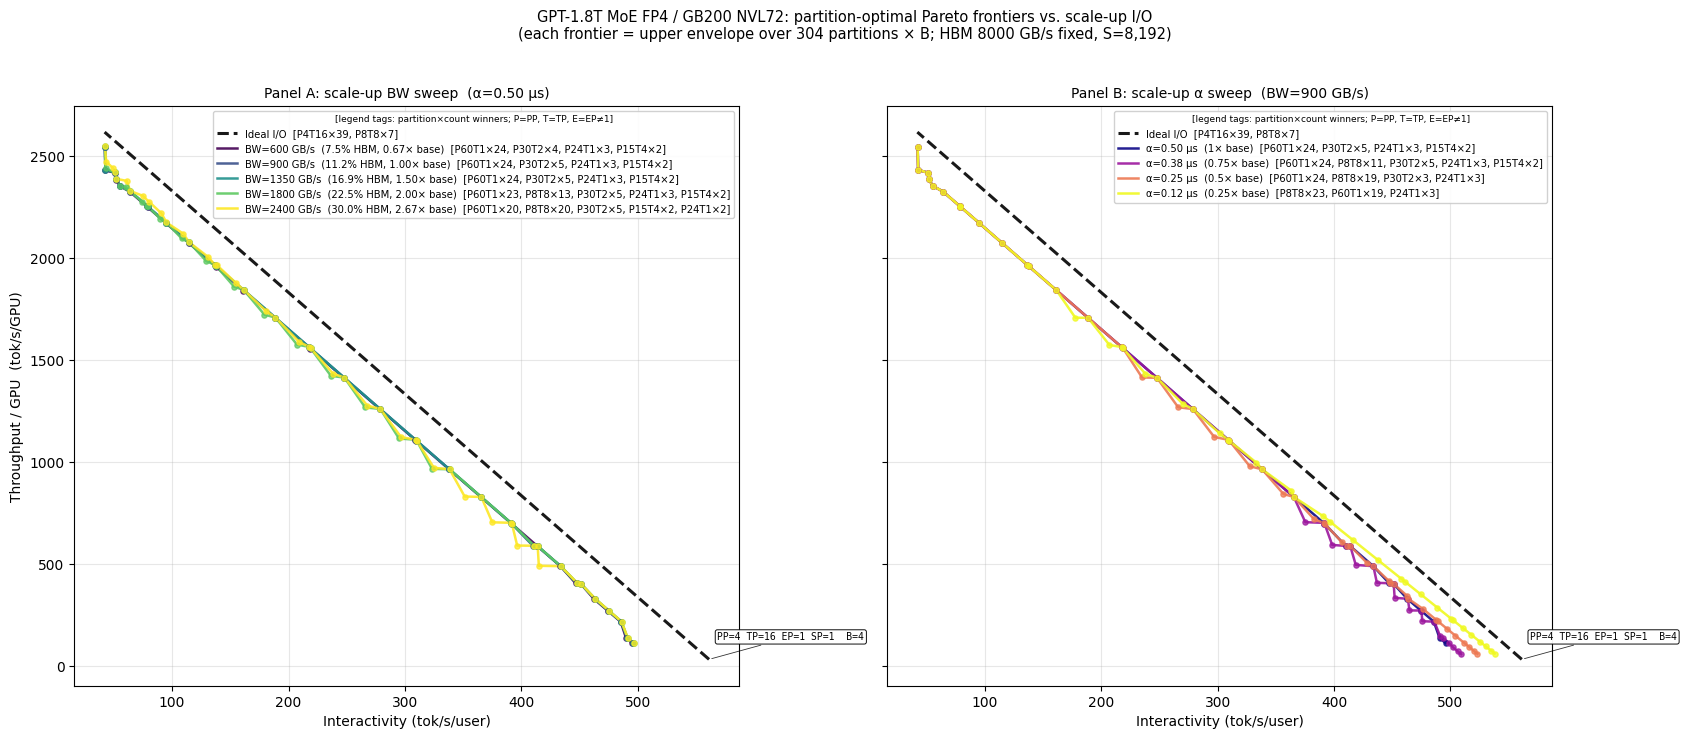

In [8]:
def winners_tag(frontier: list[Point]) -> str:
    """Compact label for legend: P=PP T=TP E=EP (drops EP=1 SP=1)."""
    counts: dict[str, int] = {}
    for p in frontier:
        counts[p.part_label] = counts.get(p.part_label, 0) + 1
    def short(name: str) -> str:
        return (name.replace(" EP=1", "").replace(" SP=1", "")
                    .replace("PP=", "P").replace("TP=", "T")
                    .replace("EP=", "E").replace(" ", ""))
    items = sorted(counts.items(), key=lambda kv: -kv[1])
    return ", ".join(f"{short(k)}×{v}" for k, v in items)


def annotate_ideal(ax, frontier, color="black"):
    """Annotate first appearance of each unique partition on the ideal curve,
    with min log-x spacing so labels don't pile up. X-axis is interactivity
    after the axis flip."""
    if not frontier:
        return
    seen: set[str] = set()
    picks: list[int] = []
    for i, p in enumerate(frontier):
        if p.part_label not in seen:
            seen.add(p.part_label); picks.append(i)
    min_log_dx = 0.30
    last_logx = -math.inf
    kept: list[int] = []
    for idx in picks:
        lx = math.log10(max(1e-9, frontier[idx].interactivity))
        if lx - last_logx >= min_log_dx:
            kept.append(idx); last_logx = lx
    offsets = [(6, 14), (6, -20), (6, 32), (6, -38)]
    for j, idx in enumerate(kept):
        p = frontier[idx]
        dx, dy = offsets[j % len(offsets)]
        ax.annotate(
            f"{p.part_label}  B={p.B}",
            xy=(p.interactivity, p.tput_per_gpu),
            xytext=(dx, dy), textcoords="offset points",
            fontsize=7, family="monospace", color="black", ha="left",
            bbox=dict(boxstyle="round,pad=0.22", fc="white",
                      ec=color, alpha=0.95, lw=0.7),
            arrowprops=dict(arrowstyle="-", color=color, lw=0.6, alpha=0.8),
        )


def plot_family(ax, curves, cmap_name, title, ideal):
    """X = interactivity (1/TPOT), Y = throughput/GPU — matches the NVIDIA
    inference-blog convention."""
    cmap = plt.get_cmap(cmap_name)
    labels = list(curves.keys())
    colors = [cmap(i / max(1, len(labels) - 1)) for i in range(len(labels))]
    if ideal:
        ax.plot([p.interactivity for p in ideal], [p.tput_per_gpu for p in ideal],
                "--", lw=2.2, color="black", alpha=0.9,
                label=f"Ideal I/O  [{winners_tag(ideal)}]", zorder=6)
    for (label, fr), color in zip(curves.items(), colors):
        if not fr:
            continue
        ax.plot([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
                "-", lw=1.8, color=color, alpha=0.9,
                label=f"{label}  [{winners_tag(fr)}]")
        ax.scatter([p.interactivity for p in fr], [p.tput_per_gpu for p in fr],
                   s=14, color=color, alpha=0.75, zorder=3)
    if ideal:
        annotate_ideal(ax, ideal, "black")
    ax.set_xscale("linear"); ax.set_yscale("linear")
    ax.set_xlabel("Interactivity (tok/s/user)")
    ax.set_title(title, fontsize=10)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(
        loc="upper right", fontsize=7.2, framealpha=0.9,
        title="[legend tags: partition×count winners; P=PP, T=TP, E=EP≠1]",
        title_fontsize=6.5,
    )


fig, axes = plt.subplots(1, 2, figsize=(17, 7.2), sharey=True)
plot_family(axes[0], bw_frontiers, "viridis",
            f"Panel A: scale-up BW sweep  (α={base_alpha:.2f} μs)",
            ideal_frontier)
plot_family(axes[1], alpha_frontiers, "plasma",
            f"Panel B: scale-up α sweep  (BW={base_bw:.0f} GB/s)",
            ideal_frontier)
axes[0].set_ylabel("Throughput / GPU  (tok/s/GPU)")
fig.suptitle(
    f"GPT-1.8T MoE FP4 / GB200 NVL72: partition-optimal Pareto frontiers vs. scale-up I/O\n"
    f"(each frontier = upper envelope over {len(partitions)} partitions × B; "
    f"HBM {hbm_bw:.0f} GB/s fixed, S={S_DECODE:,})",
    fontsize=10.5, y=1.02,
)
fig.tight_layout()
fig.savefig("assets/pareto_vs_io.png", dpi=130, bbox_inches="tight")
print("Saved -> assets/pareto_vs_io.png")
plt.show()

## 8. What to take away

- At baseline scale-up I/O (1× base BW, 1× α) one or two partitions dominate the frontier — winners call out the shape that balances HBM BW against collective cost at each batch corner.
- As scale-up BW *grows* (toward the 20% HBM ceiling), the frontier saturates: further BW stops helping once HBM is the new bottleneck.
- The **ideal-I/O reference** (dashed) uses a different optimal partition than the realistic case — showing that if scale-up were free, the winning shape would tilt toward wider TP and shallower pipeline (or vice-versa, depending on the model).
- The α sweep is much flatter than the BW sweep: for long-sequence decode, message *size* dominates over message *count*, so α perturbations barely move the frontier.